#Import dữ liệu

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

In [59]:
# Đường dẫn đến file excel của bạn
# Đây là đường dẫn tới file bạn đã upload lên môi trường làm việc
file_path = "/content/Adidas US Sales Datasets.xlsx"
df = pd.read_excel(file_path)
df.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13
0,NaN,NaN,Adidas Sales Database,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,Retailer,Retailer ID,Invoice Date,Region,State,City,Product,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin,Sales Method
4,NaN,Foot Locker,1185732,2020-01-01 00:00:00,Northeast,New York,New York,Men's Street Footwear,50,1200,600000,300000,0.5,In-store


#Làm sạch dữ liệu

In [60]:
#Lấy từ dòng thứ 5 trong file
df = pd.read_excel(file_path, header=4)
# Bỏ cột 'Unnamed: 0' nếu nó tồn tại
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
df

,Retailer,Retailer ID,Invoice Date,Region,State,City,Product,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin,Sales Method
0,Foot Locker,1185732,2020-01-01,Northeast,New York,New York,Men's Street Footwear,50.0,1200,600000.0,300000.00,0.50,In-store
1,Foot Locker,1185732,2020-01-02,Northeast,New York,New York,Men's Athletic Footwear,50.0,1000,500000.0,150000.00,0.30,In-store
2,Foot Locker,1185732,2020-01-03,Northeast,New York,New York,Women's Street Footwear,40.0,1000,400000.0,140000.00,0.35,In-store
3,Foot Locker,1185732,2020-01-04,Northeast,New York,New York,Women's Athletic Footwear,45.0,850,382500.0,133875.00,0.35,In-store
4,Foot Locker,1185732,2020-01-05,Northeast,New York,New York,Men's Apparel,60.0,900,540000.0,162000.00,0.30,In-store
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9643,Foot Locker,1185732,2021-01-24,Northeast,New Hampshire,Manchester,Men's Apparel,50.0,64,3200.0,896.00,0.28,Outlet
9644,Foot Locker,1185732,2021-01-24,Northeast,New Hampshire,Manchester,Women's Apparel,41.0,105,4305.0,1377.60,0.32,Outlet
9645,Foot Locker,1185732,2021-02-22,Northeast,New Hampshire,Manchester,Men's Street Footwear,41.0,184,7544.0,2791.28,0.37,Outlet
9646,Foot Locker,1185732,2021-02-22,Northeast,New Hampshire,Manchester,Men's Athletic Footwear,42.0,70,2940.0,1234.80,0.42,Outlet


In [61]:
df.shape

(9648, 13)

In [62]:
print("Thông tin DataFrame :")
df.info()

Thông tin DataFrame :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9648 entries, 0 to 9647
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Retailer          9648 non-null   object        
 1   Retailer ID       9648 non-null   int64         
 2   Invoice Date      9648 non-null   datetime64[ns]
 3   Region            9648 non-null   object        
 4   State             9648 non-null   object        
 5   City              9648 non-null   object        
 6   Product           9648 non-null   object        
 7   Price per Unit    9648 non-null   float64       
 8   Units Sold        9648 non-null   int64         
 9   Total Sales       9648 non-null   float64       
 10  Operating Profit  9648 non-null   float64       
 11  Operating Margin  9648 non-null   float64       
 12  Sales Method      9648 non-null   object        
dtypes: datetime64[ns](1), float64(4), int64(2), object(6)
me

In [63]:
df.isna().sum()

,0
Retailer,0
Retailer ID,0
Invoice Date,0
Region,0
State,0
City,0
Product,0
Price per Unit,0
Units Sold,0
Total Sales,0


In [64]:
df.duplicated().sum()

np.int64(0)

In [65]:
#Tạo biến mới
df['Revenue'] = df['Price per Unit'] * df['Units Sold']

In [66]:
# Lọc các dòng bị lệch
mismatch_df = df[df["Revenue"] != df["Total Sales"]]

# Xem kết quả
mismatch_df

,Retailer,Retailer ID,Invoice Date,Region,State,City,Product,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin,Sales Method,Revenue
0,Foot Locker,1185732,2020-01-01,Northeast,New York,New York,Men's Street Footwear,50.0,1200,600000.0,300000.0,0.50,In-store,60000.0
1,Foot Locker,1185732,2020-01-02,Northeast,New York,New York,Men's Athletic Footwear,50.0,1000,500000.0,150000.0,0.30,In-store,50000.0
2,Foot Locker,1185732,2020-01-03,Northeast,New York,New York,Women's Street Footwear,40.0,1000,400000.0,140000.0,0.35,In-store,40000.0
3,Foot Locker,1185732,2020-01-04,Northeast,New York,New York,Women's Athletic Footwear,45.0,850,382500.0,133875.0,0.35,In-store,38250.0
4,Foot Locker,1185732,2020-01-05,Northeast,New York,New York,Men's Apparel,60.0,900,540000.0,162000.0,0.30,In-store,54000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3883,Foot Locker,1185732,2021-01-24,Northeast,New Hampshire,Manchester,Men's Apparel,65.0,200,130000.0,32500.0,0.25,Outlet,13000.0
3884,Foot Locker,1185732,2021-01-24,Northeast,New Hampshire,Manchester,Women's Apparel,55.0,300,165000.0,49500.0,0.30,Outlet,16500.0
3885,Foot Locker,1185732,2021-02-22,Northeast,New Hampshire,Manchester,Men's Street Footwear,55.0,575,316250.0,110687.5,0.35,Outlet,31625.0
3886,Foot Locker,1185732,2021-02-22,Northeast,New Hampshire,Manchester,Men's Athletic Footwear,55.0,225,123750.0,43312.5,0.35,Outlet,12375.0


In [67]:
df['Profit']= df['Revenue']*df['Operating Margin']


In [68]:
df = df.drop(columns=['Total Sales', 'Operating Profit'])
print("DataFrame after dropping columns:")
df

DataFrame after dropping columns:


,Retailer,Retailer ID,Invoice Date,Region,State,City,Product,Price per Unit,Units Sold,Operating Margin,Sales Method,Revenue,Profit
0,Foot Locker,1185732,2020-01-01,Northeast,New York,New York,Men's Street Footwear,50.0,1200,0.50,In-store,60000.0,30000.00
1,Foot Locker,1185732,2020-01-02,Northeast,New York,New York,Men's Athletic Footwear,50.0,1000,0.30,In-store,50000.0,15000.00
2,Foot Locker,1185732,2020-01-03,Northeast,New York,New York,Women's Street Footwear,40.0,1000,0.35,In-store,40000.0,14000.00
3,Foot Locker,1185732,2020-01-04,Northeast,New York,New York,Women's Athletic Footwear,45.0,850,0.35,In-store,38250.0,13387.50
4,Foot Locker,1185732,2020-01-05,Northeast,New York,New York,Men's Apparel,60.0,900,0.30,In-store,54000.0,16200.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9643,Foot Locker,1185732,2021-01-24,Northeast,New Hampshire,Manchester,Men's Apparel,50.0,64,0.28,Outlet,3200.0,896.00
9644,Foot Locker,1185732,2021-01-24,Northeast,New Hampshire,Manchester,Women's Apparel,41.0,105,0.32,Outlet,4305.0,1377.60
9645,Foot Locker,1185732,2021-02-22,Northeast,New Hampshire,Manchester,Men's Street Footwear,41.0,184,0.37,Outlet,7544.0,2791.28
9646,Foot Locker,1185732,2021-02-22,Northeast,New Hampshire,Manchester,Men's Athletic Footwear,42.0,70,0.42,Outlet,2940.0,1234.80


In [69]:
df = df.rename(columns={'Operating Margin': 'Profit Margin'})
print("DataFrame after renaming 'Operating Margin' to 'Profit Margin':")
display(df.head())

DataFrame after renaming 'Operating Margin' to 'Profit Margin':


,Retailer,Retailer ID,Invoice Date,Region,State,City,Product,Price per Unit,Units Sold,Profit Margin,Sales Method,Revenue,Profit
0,Foot Locker,1185732,2020-01-01,Northeast,New York,New York,Men's Street Footwear,50.0,1200,0.50,In-store,60000.0,30000.0
1,Foot Locker,1185732,2020-01-02,Northeast,New York,New York,Men's Athletic Footwear,50.0,1000,0.30,In-store,50000.0,15000.0
2,Foot Locker,1185732,2020-01-03,Northeast,New York,New York,Women's Street Footwear,40.0,1000,0.35,In-store,40000.0,14000.0
3,Foot Locker,1185732,2020-01-04,Northeast,New York,New York,Women's Athletic Footwear,45.0,850,0.35,In-store,38250.0,13387.5
4,Foot Locker,1185732,2020-01-05,Northeast,New York,New York,Men's Apparel,60.0,900,0.30,In-store,54000.0,16200.0


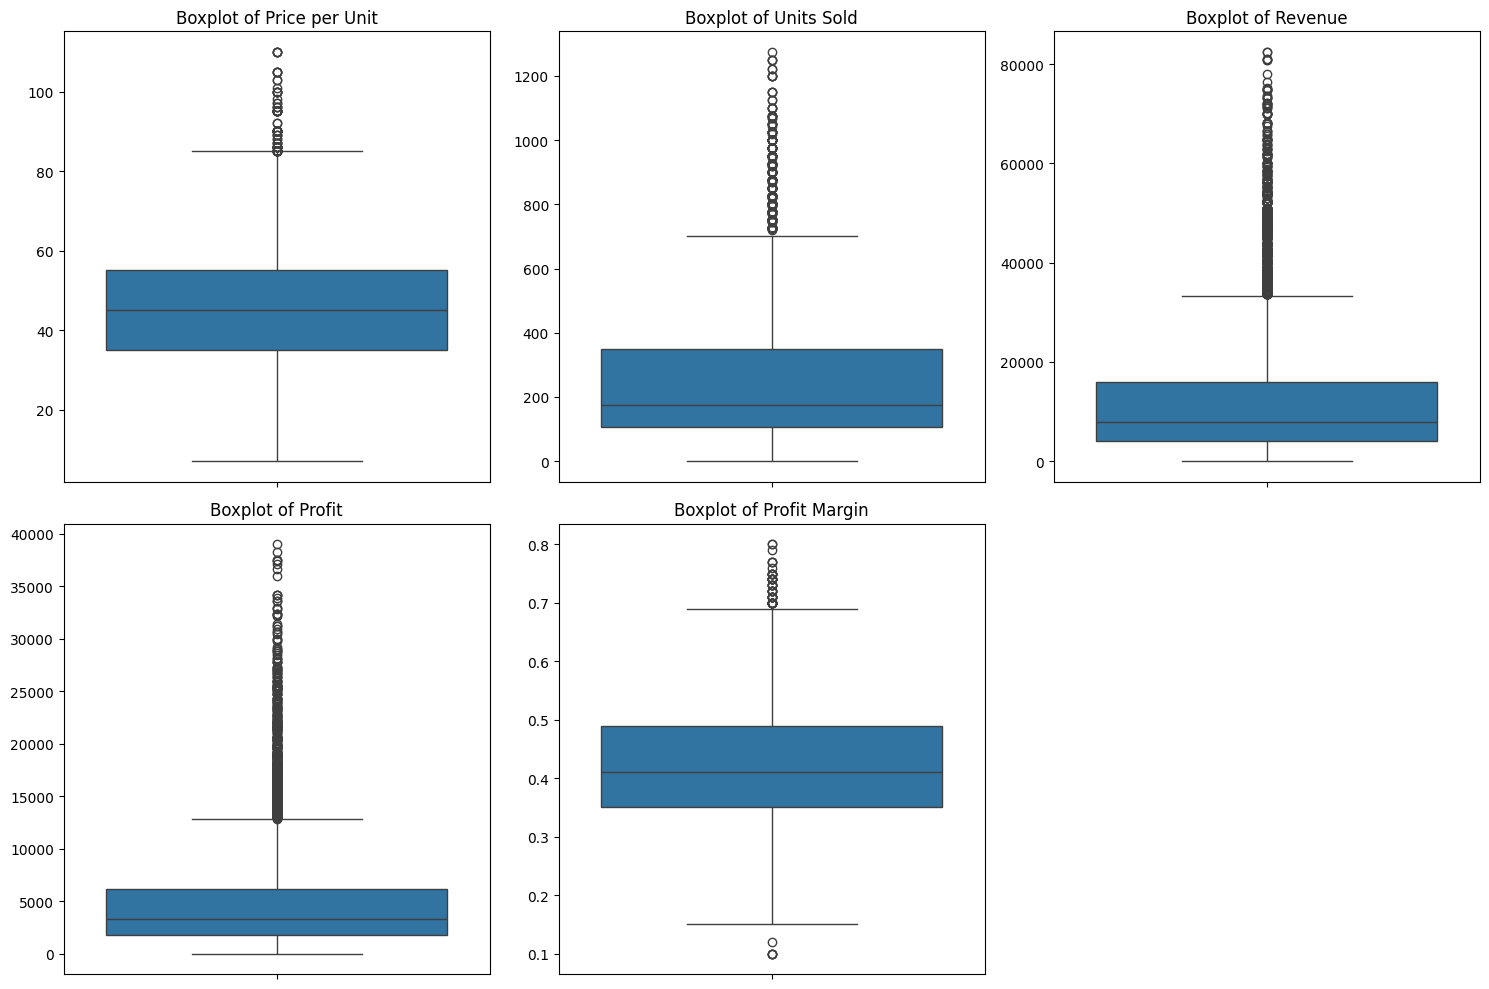

In [70]:
#Kiểm tra outliers
numerical_cols = ['Price per Unit', 'Units Sold', 'Revenue', 'Profit', 'Profit Margin']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1)  # Tạo lưới 2 hàng × 3 cột
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel('') # Xóa nhãn trục y tránh rối mắt
plt.tight_layout()
plt.show()

In [71]:
# Xóa dòng có 'Units Sold' bằng  0
df = df[df['Units Sold'] != 0]

print("DataFrame after removing rows with 0 Units Sold:")
display(df.head())

DataFrame after removing rows with 0 Units Sold:


,Retailer,Retailer ID,Invoice Date,Region,State,City,Product,Price per Unit,Units Sold,Profit Margin,Sales Method,Revenue,Profit
0,Foot Locker,1185732,2020-01-01,Northeast,New York,New York,Men's Street Footwear,50.0,1200,0.50,In-store,60000.0,30000.0
1,Foot Locker,1185732,2020-01-02,Northeast,New York,New York,Men's Athletic Footwear,50.0,1000,0.30,In-store,50000.0,15000.0
2,Foot Locker,1185732,2020-01-03,Northeast,New York,New York,Women's Street Footwear,40.0,1000,0.35,In-store,40000.0,14000.0
3,Foot Locker,1185732,2020-01-04,Northeast,New York,New York,Women's Athletic Footwear,45.0,850,0.35,In-store,38250.0,13387.5
4,Foot Locker,1185732,2020-01-05,Northeast,New York,New York,Men's Apparel,60.0,900,0.30,In-store,54000.0,16200.0


In [72]:
# Danh sách cột cần xử lý
cols_to_process = ['Price per Unit', 'Units Sold', 'Revenue', 'Profit', 'Profit Margin']
df_cap = df.copy()

In [73]:
#Thực hiện Capping theo phân vị (ví dụ chọn 99th để giữ tối đa thông tin)
for col in cols_to_process:
    lower_val = df_cap[col].quantile(0.01) # Phân vị 1% (cho phần đuôi dưới)
    upper_val = df_cap[col].quantile(0.99) # Phân vị 99% (cho phần đuôi trên)

    # Ghi chú: Với Revenue/Profit thường chỉ cần Cap đầu trên,
    # nhưng với Profit Margin có thể cần Cap cả đầu dưới.
    df_cap[col] = df_cap[col].clip(lower=lower_val, upper=upper_val)

print("Đã hoàn thành Capping tại phân vị 1% và 99%.")

Đã hoàn thành Capping tại phân vị 1% và 99%.


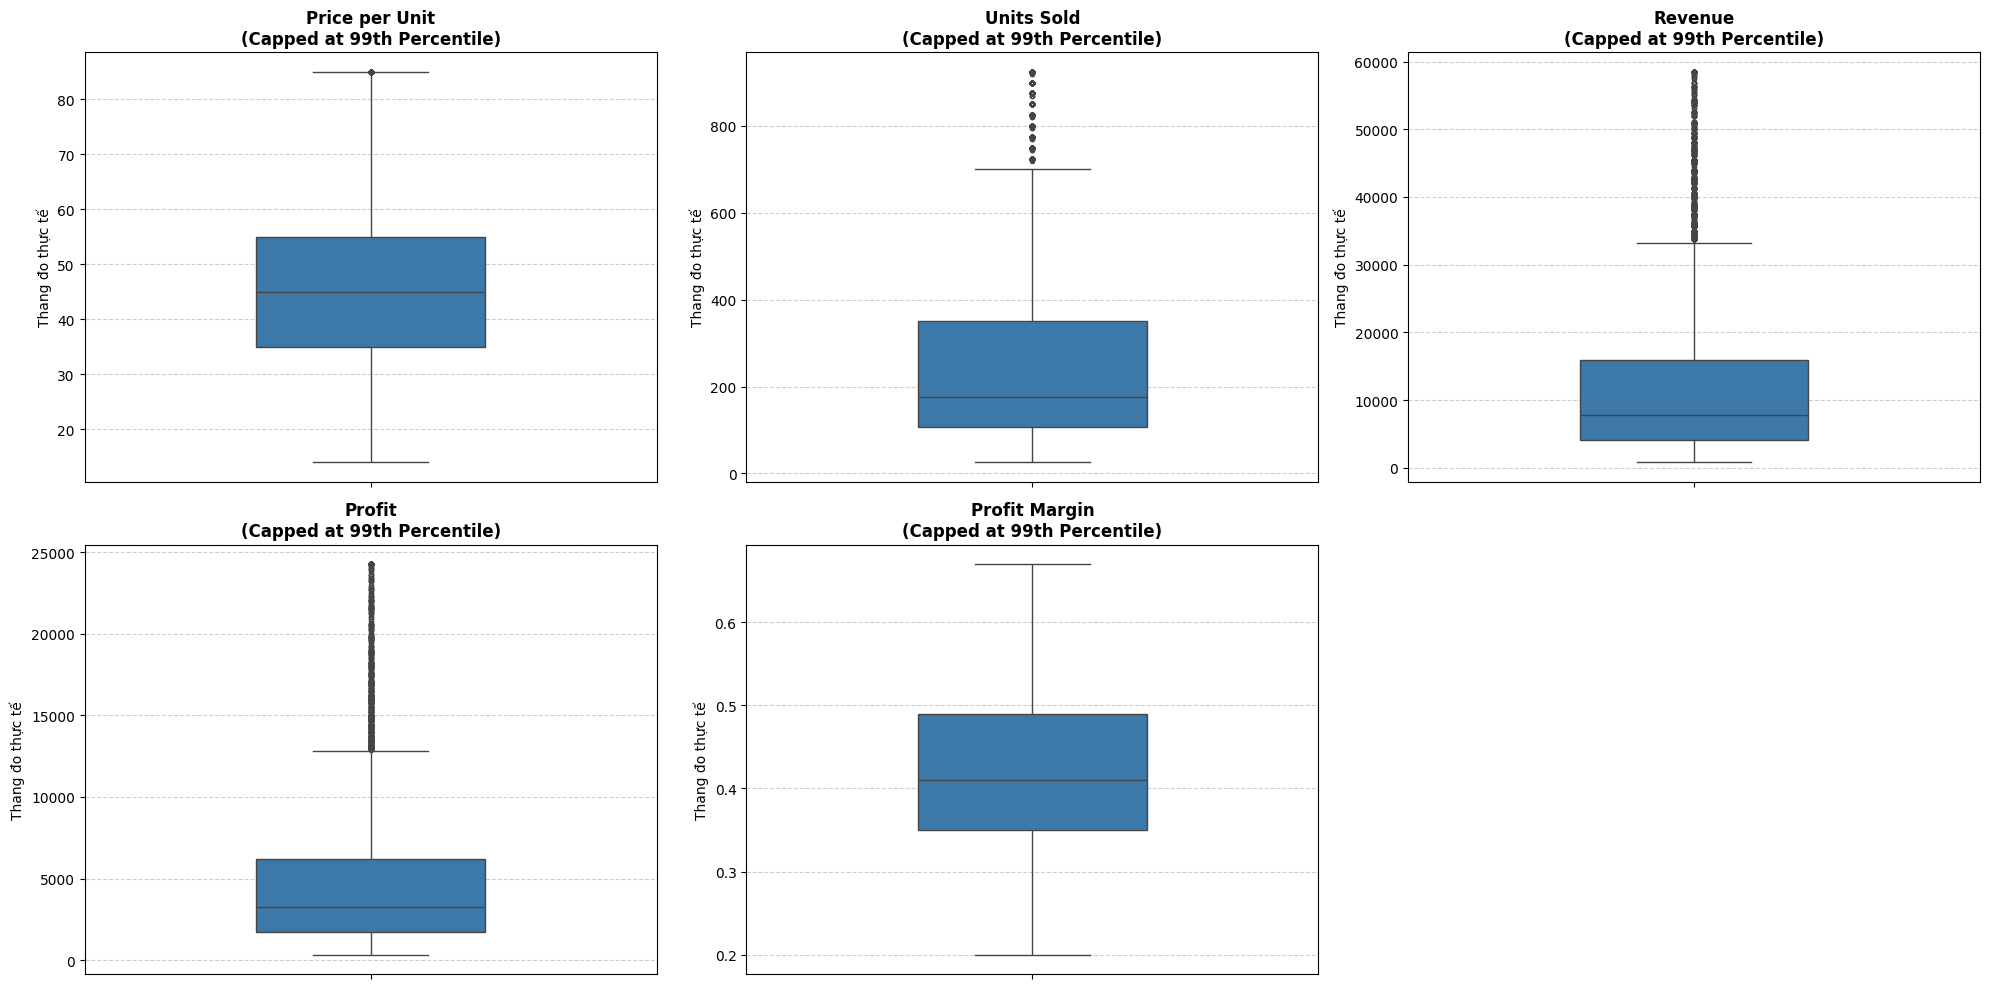

In [74]:
# Vẽ biểu đồ so sánh (Trực quan hóa cho báo cáo)
plt.figure(figsize=(20, 10))
for i, col in enumerate(cols_to_process):
    plt.subplot(2, 3, i + 1)

    # Vẽ Boxplot với tông màu chuyên nghiệp cho báo cáo
    sns.boxplot(y=df_cap[col], color='#2b7bba', width=0.4, fliersize=3)

    plt.title(f'{col}\n(Capped at 99th Percentile)', fontsize=12, fontweight='bold')
    plt.ylabel('Thang đo thực tế')
    plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

#Mô tả dữ liệu

In [75]:
print("\nThống kê mô tả các cột số:")
df.describe()


Thống kê mô tả các cột số:


,Retailer ID,Invoice Date,Price per Unit,Units Sold,Profit Margin,Revenue,Profit
count,9.644000e+03,9644,9644.000000,9644.000000,9644.000000,9644.000000,9644.000000
mean,1.173845e+06,2021-05-10 15:03:48.452923904,45.222418,257.036603,0.422972,12460.249896,4896.823693
min,1.128299e+06,2020-01-01 00:00:00,7.000000,6.000000,0.100000,160.000000,75.200000
25%,1.185732e+06,2021-02-17 00:00:00,35.000000,106.000000,0.350000,4068.000000,1753.965000
50%,1.185732e+06,2021-06-04 00:00:00,45.000000,176.000000,0.410000,7812.000000,3264.000000
75%,1.185732e+06,2021-09-16 00:00:00,55.000000,350.000000,0.490000,15872.000000,6193.830000
max,1.197831e+06,2021-12-31 00:00:00,110.000000,1275.000000,0.800000,82500.000000,39000.000000
std,2.636473e+04,NaN,14.705565,214.232536,0.097202,12716.498341,4866.452163


In [76]:
df.describe(include = object)

,Retailer,Region,State,City,Product,Sales Method
count,9644,9644,9644,9644,9644,9644
unique,6,5,50,52,6,3
top,Foot Locker,West,Texas,Portland,Men's Street Footwear,Online
freq,2633,2448,432,360,1610,4887


* Retailer

In [77]:
df['Retailer'].unique()

array(['Foot Locker', 'Walmart', 'Sports Direct', 'West Gear', "Kohl's",
       'Amazon'], dtype=object)

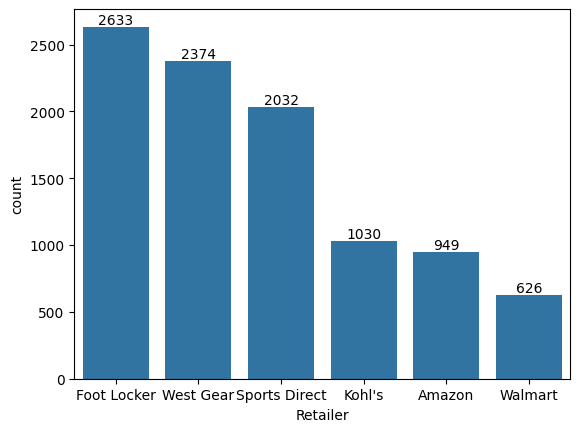

In [78]:
graph = sns.countplot(x = "Retailer", data = df, order = df.Retailer.value_counts().index)
for container in graph.containers:
    graph.bar_label(container)
plt.show()

* Invoice Date

In [79]:
df["Invoice Date"].unique()

<DatetimeArray>
['2020-01-01 00:00:00', '2020-01-02 00:00:00', '2020-01-03 00:00:00',
 '2020-01-04 00:00:00', '2020-01-05 00:00:00', '2020-01-06 00:00:00',
 '2020-01-07 00:00:00', '2020-01-08 00:00:00', '2020-01-21 00:00:00',
 '2020-01-22 00:00:00',
 ...
 '2021-03-27 00:00:00', '2021-03-28 00:00:00', '2021-03-29 00:00:00',
 '2021-03-30 00:00:00', '2021-03-31 00:00:00', '2021-04-01 00:00:00',
 '2021-04-02 00:00:00', '2021-04-03 00:00:00', '2021-04-04 00:00:00',
 '2021-04-05 00:00:00']
Length: 724, dtype: datetime64[ns]

In [80]:
df = df.sort_values(by='Invoice Date').reset_index(drop=True)
print("DataFrame after sorting by 'Invoice Date':")
df

DataFrame after sorting by 'Invoice Date':


,Retailer,Retailer ID,Invoice Date,Region,State,City,Product,Price per Unit,Units Sold,Profit Margin,Sales Method,Revenue,Profit
0,Foot Locker,1185732,2020-01-01,Northeast,New York,New York,Men's Street Footwear,50.0,1200,0.50,In-store,60000.0,30000.00
1,Foot Locker,1185732,2020-01-01,Northeast,Pennsylvania,Philadelphia,Women's Apparel,75.0,275,0.30,Outlet,20625.0,6187.50
2,Foot Locker,1185732,2020-01-01,Northeast,Pennsylvania,Philadelphia,Women's Apparel,53.0,83,0.32,Outlet,4399.0,1407.68
3,Foot Locker,1185732,2020-01-01,Northeast,New York,New York,Men's Street Footwear,47.0,336,0.61,Online,15792.0,9633.12
4,Foot Locker,1185732,2020-01-01,Northeast,New York,New York,Men's Street Footwear,34.0,384,0.52,Outlet,13056.0,6789.12
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9639,Foot Locker,1185732,2021-12-31,Northeast,Pennsylvania,Philadelphia,Men's Apparel,63.0,47,0.46,Online,2961.0,1362.06
9640,Foot Locker,1185732,2021-12-31,Northeast,Pennsylvania,Philadelphia,Men's Apparel,70.0,175,0.35,Outlet,12250.0,4287.50
9641,Amazon,1185732,2021-12-31,Northeast,Maine,Portland,Men's Apparel,52.0,36,0.37,Online,1872.0,692.64
9642,Foot Locker,1185732,2021-12-31,Northeast,Pennsylvania,Philadelphia,Men's Apparel,46.0,56,0.39,Outlet,2576.0,1004.64


In [81]:
# Tạo cột tháng

df['Month'] = df['Invoice Date'].dt.month
df['Month']

,Month
0,1
1,1
2,1
3,1
4,1
...,...
9639,12
9640,12
9641,12
9642,12


In [82]:
# Tạo cột năm

df['Year'] = df['Invoice Date'].dt.year
df['Year']

,Year
0,2020
1,2020
2,2020
3,2020
4,2020
...,...
9639,2021
9640,2021
9641,2021
9642,2021


In [83]:
# Create a new 'Season' column based on the 'Month'
def get_season(month):
    if 1 <= month <= 3:
        return 'Spring'
    elif 4 <= month <= 6:
        return 'Summer'
    elif 7 <= month <= 9:
        return 'Autumn'
    else:
        return 'Winter'

df['Season'] = df['Month'].apply(get_season)
print("DataFrame with new 'Season' column (first 5 rows):")
df.head()

DataFrame with new 'Season' column (first 5 rows):


,Retailer,Retailer ID,Invoice Date,Region,State,City,Product,Price per Unit,Units Sold,Profit Margin,Sales Method,Revenue,Profit,Month,Year,Season
0,Foot Locker,1185732,2020-01-01,Northeast,New York,New York,Men's Street Footwear,50.0,1200,0.50,In-store,60000.0,30000.00,1,2020,Spring
1,Foot Locker,1185732,2020-01-01,Northeast,Pennsylvania,Philadelphia,Women's Apparel,75.0,275,0.30,Outlet,20625.0,6187.50,1,2020,Spring
2,Foot Locker,1185732,2020-01-01,Northeast,Pennsylvania,Philadelphia,Women's Apparel,53.0,83,0.32,Outlet,4399.0,1407.68,1,2020,Spring
3,Foot Locker,1185732,2020-01-01,Northeast,New York,New York,Men's Street Footwear,47.0,336,0.61,Online,15792.0,9633.12,1,2020,Spring
4,Foot Locker,1185732,2020-01-01,Northeast,New York,New York,Men's Street Footwear,34.0,384,0.52,Outlet,13056.0,6789.12,1,2020,Spring


In [84]:
#Tên tháng
df['Month'] = pd.to_datetime(df['Month'], format='%m').dt.month_name()

In [85]:
# giữ tháng dạng số (lấy từ tên tháng đầy đủ)
df['Month_num'] = pd.to_datetime(df['Month'], format='%B').dt.month

# chuyển sang tên tháng viết tắt (từ tên tháng đầy đủ)
df['Month_name'] = pd.to_datetime(df['Month'], format='%B').dt.strftime('%b')  # Jan, Feb

# fix thứ tự
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
df['Month_name'] = pd.Categorical(df['Month_name'], categories=month_order, ordered=True)

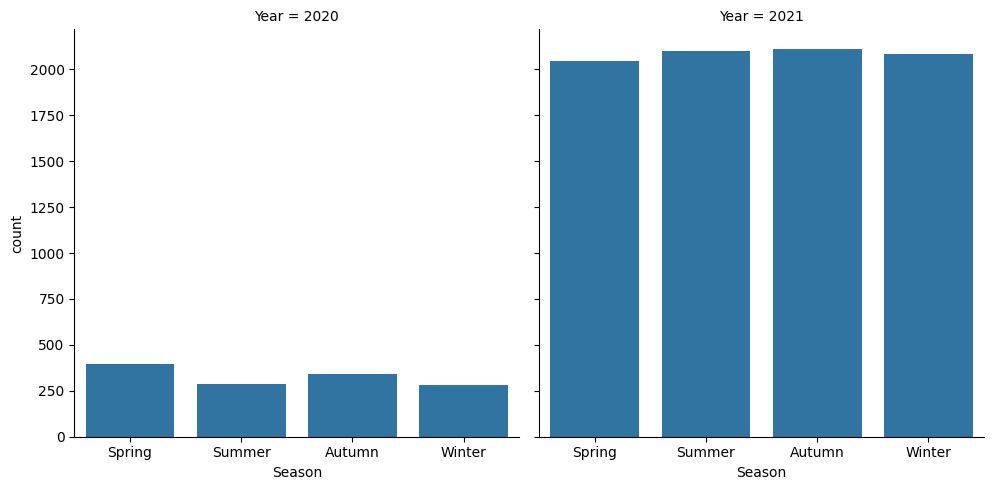

In [86]:
graph = sns.catplot(x = "Season", col = "Year", data = df, kind = "count")
plt.show()

In [87]:
#Xóa cột Retailer ID và cột Invoice Date
df.drop(columns = ['Retailer ID', 'Invoice Date'], inplace = True)

* Region

In [88]:
df['Region'].unique()

array(['Northeast', 'West', 'Southeast', 'South', 'Midwest'], dtype=object)

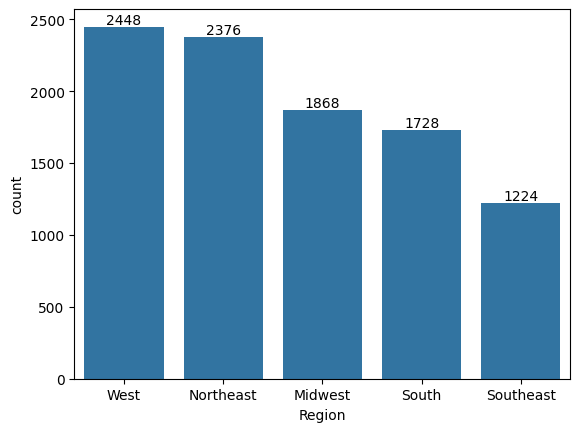

In [89]:
graph = sns.countplot(x = "Region", data = df, order = df.Region.value_counts().index)
for container in graph.containers:
    graph.bar_label(container)
plt.show()

* State

In [90]:
df['State'].unique()

array(['New York', 'Pennsylvania', 'Nevada', 'Colorado', 'Florida',
       'Washington', 'Texas', 'Minnesota', 'California', 'Montana',
       'Iowa', 'Louisiana', 'South Carolina', 'North Dakota',
       'New Jersey', 'Georgia', 'South Dakota', 'Alaska', 'Maine',
       'Delaware', 'Connecticut', 'Wisconsin', 'Missouri', 'Kansas',
       'North Carolina', 'New Mexico', 'Massachusetts', 'Oklahoma',
       'Indiana', 'Maryland', 'Hawaii', 'Rhode Island', 'Oregon',
       'Michigan', 'Virginia', 'Kentucky', 'Vermont', 'Ohio',
       'Mississippi', 'Arkansas', 'Idaho', 'West Virginia',
       'New Hampshire', 'Utah', 'Wyoming', 'Arizona', 'Tennessee',
       'Nebraska', 'Illinois', 'Alabama'], dtype=object)

/tmp/ipykernel_6479/941832233.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




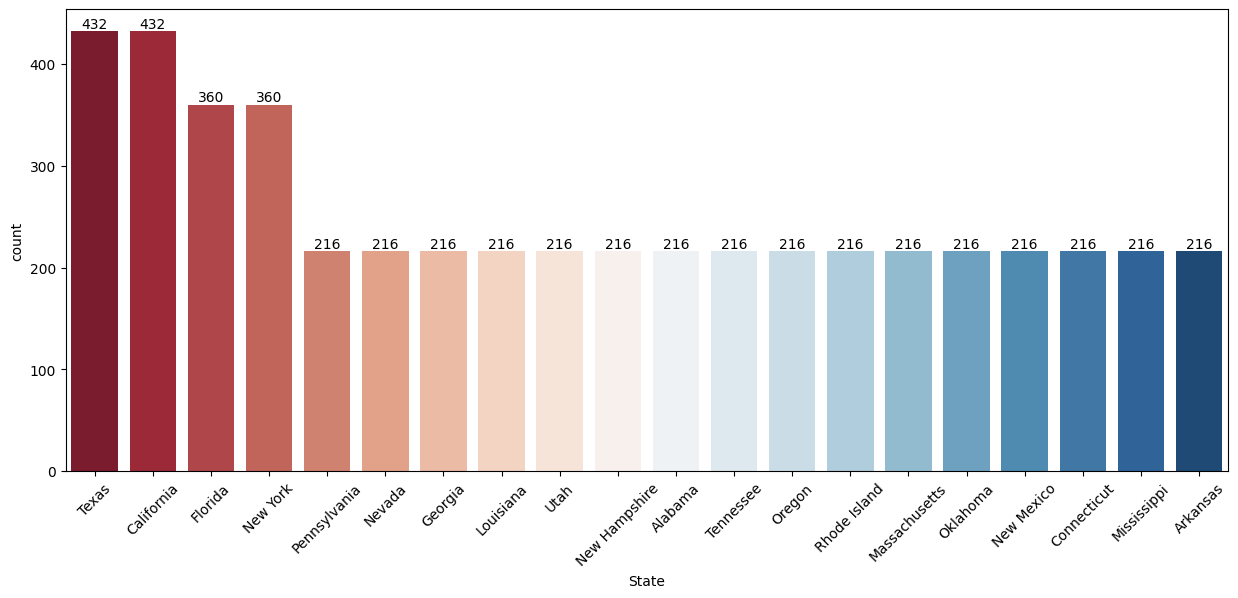

In [91]:
plt.figure(figsize = (15,6))
graph = sns.countplot(x = "State", data = df, order = df.State.value_counts()[:20].index, palette = "RdBu")
for container in graph.containers:
    graph.bar_label(container)

plt.xticks(rotation = 45)
plt.show()

* City

In [92]:
df['City'].unique()

array(['New York', 'Philadelphia', 'Las Vegas', 'Denver', 'Miami',
       'Seattle', 'Houston', 'Minneapolis', 'San Francisco', 'Billings',
       'Des Moines', 'New Orleans', 'Charleston', 'Fargo', 'Newark',
       'Atlanta', 'Sioux Falls', 'Anchorage', 'Portland', 'Wilmington',
       'Hartford', 'Milwaukee', 'St. Louis', 'Orlando', 'Wichita',
       'Charlotte', 'Albuquerque', 'Albany', 'Boston', 'Oklahoma City',
       'Indianapolis', 'Baltimore', 'Honolulu', 'Providence', 'Detroit',
       'Richmond', 'Louisville', 'Burlington', 'Columbus', 'Jackson',
       'Little Rock', 'Boise', 'Manchester', 'Salt Lake City', 'Cheyenne',
       'Phoenix', 'Los Angeles', 'Knoxville', 'Omaha', 'Chicago',
       'Birmingham', 'Dallas'], dtype=object)

/tmp/ipykernel_6479/3890793429.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




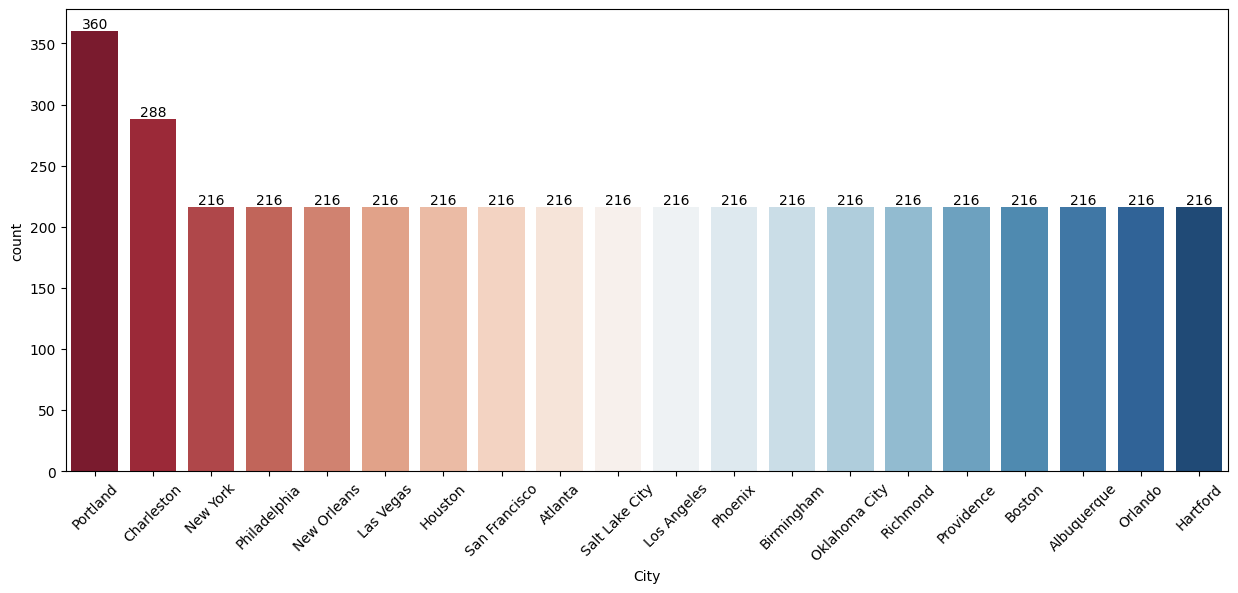

In [93]:
plt.figure(figsize = (15,6))
graph = sns.countplot(x = "City", data = df, order = df.City.value_counts()[:20].index, palette = "RdBu")
for container in graph.containers:
    graph.bar_label(container)

plt.xticks(rotation = 45)
plt.show()

* Product

In [94]:
print(df['Product'].unique())

["Men's Street Footwear" "Women's Apparel" "Men's Athletic Footwear"
 "Women's Street Footwear" "Women's Athletic Footwear" "Men's Apparel"]


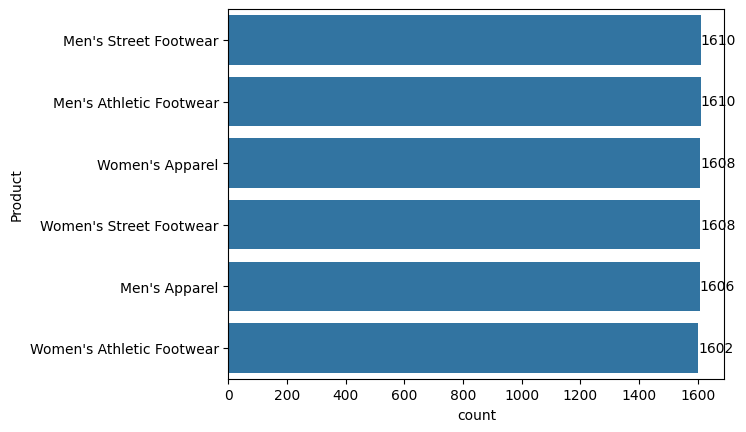

In [95]:
graph = sns.countplot(y = "Product", data = df, order = df.Product.value_counts().index)
for container in graph.containers:
    graph.bar_label(container)
plt.show()

* Unit Sold

In [96]:
df_cap['Units Sold'].unique()

array([925, 850, 900, 825, 800, 875, 920, 700, 550, 675, 625, 500, 600,
       650, 725, 525, 775, 750, 575, 450, 425, 475, 275, 125, 175, 225,
       100, 495, 200,  75, 150, 250, 350, 325, 400, 375, 300, 195,  50,
       445,  26, 470, 745, 145, 420,  95, 545, 570, 320, 870, 820, 520,
       770, 795, 620, 295, 670, 345, 695, 595, 220, 720, 395, 645, 245,
       270, 170, 336, 260, 247, 234, 313, 261, 276, 206, 243, 290, 354,
       259, 216, 230, 238, 252, 239, 215, 317, 278, 305, 319, 267, 231,
       286, 308, 257, 241, 360, 268, 280, 236, 299, 273, 258, 254, 263,
       312, 285, 210, 154, 203, 213, 255, 176, 196, 182, 174, 189, 163,
       147, 232, 168, 169, 293, 297, 181, 240, 188, 209, 194, 217, 161,
       233, 223, 140, 228, 152, 218, 248, 155, 219, 277, 202, 208, 160,
       113, 106, 156, 119, 131, 221, 224, 124,  77,  83,  34,  47,  69,
       158,  51,  61,  28,  44, 144,  60,  68,  38,  63, 122,  42,  65,
       134,  54,  35, 135, 105,  81,  56, 120, 149,  94,  84,  4

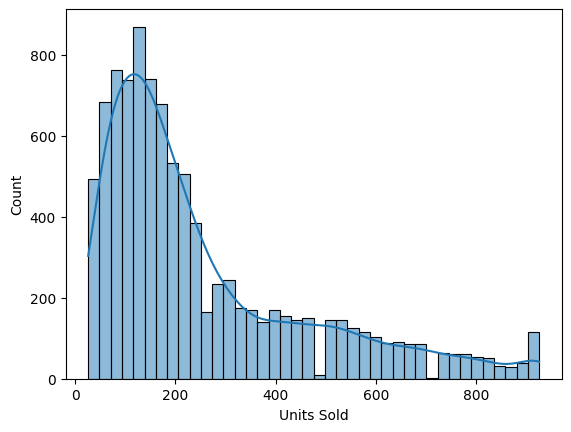

In [97]:
sns.histplot(data = df_cap, x = "Units Sold", kde=True)
plt.show()

* Sale Method

In [98]:
df['Sales Method'].unique()

array(['In-store', 'Outlet', 'Online'], dtype=object)

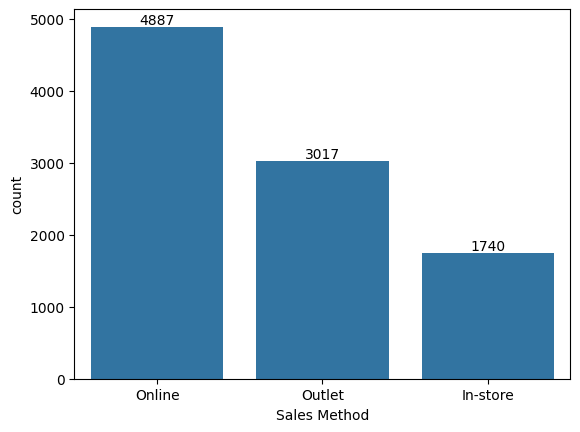

In [99]:
graph = sns.countplot(x = "Sales Method", data = df, order = df['Sales Method'].value_counts().index)
for container in graph.containers:
    graph.bar_label(container)
plt.show()

* Tần suất và phân phối

In [100]:
df

,Retailer,Region,State,City,Product,Price per Unit,Units Sold,Profit Margin,Sales Method,Revenue,Profit,Month,Year,Season,Month_num,Month_name
0,Foot Locker,Northeast,New York,New York,Men's Street Footwear,50.0,1200,0.50,In-store,60000.0,30000.00,January,2020,Spring,1,Jan
1,Foot Locker,Northeast,Pennsylvania,Philadelphia,Women's Apparel,75.0,275,0.30,Outlet,20625.0,6187.50,January,2020,Spring,1,Jan
2,Foot Locker,Northeast,Pennsylvania,Philadelphia,Women's Apparel,53.0,83,0.32,Outlet,4399.0,1407.68,January,2020,Spring,1,Jan
3,Foot Locker,Northeast,New York,New York,Men's Street Footwear,47.0,336,0.61,Online,15792.0,9633.12,January,2020,Spring,1,Jan
4,Foot Locker,Northeast,New York,New York,Men's Street Footwear,34.0,384,0.52,Outlet,13056.0,6789.12,January,2020,Spring,1,Jan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9639,Foot Locker,Northeast,Pennsylvania,Philadelphia,Men's Apparel,63.0,47,0.46,Online,2961.0,1362.06,December,2021,Winter,12,Dec
9640,Foot Locker,Northeast,Pennsylvania,Philadelphia,Men's Apparel,70.0,175,0.35,Outlet,12250.0,4287.50,December,2021,Winter,12,Dec
9641,Amazon,Northeast,Maine,Portland,Men's Apparel,52.0,36,0.37,Online,1872.0,692.64,December,2021,Winter,12,Dec
9642,Foot Locker,Northeast,Pennsylvania,Philadelphia,Men's Apparel,46.0,56,0.39,Outlet,2576.0,1004.64,December,2021,Winter,12,Dec


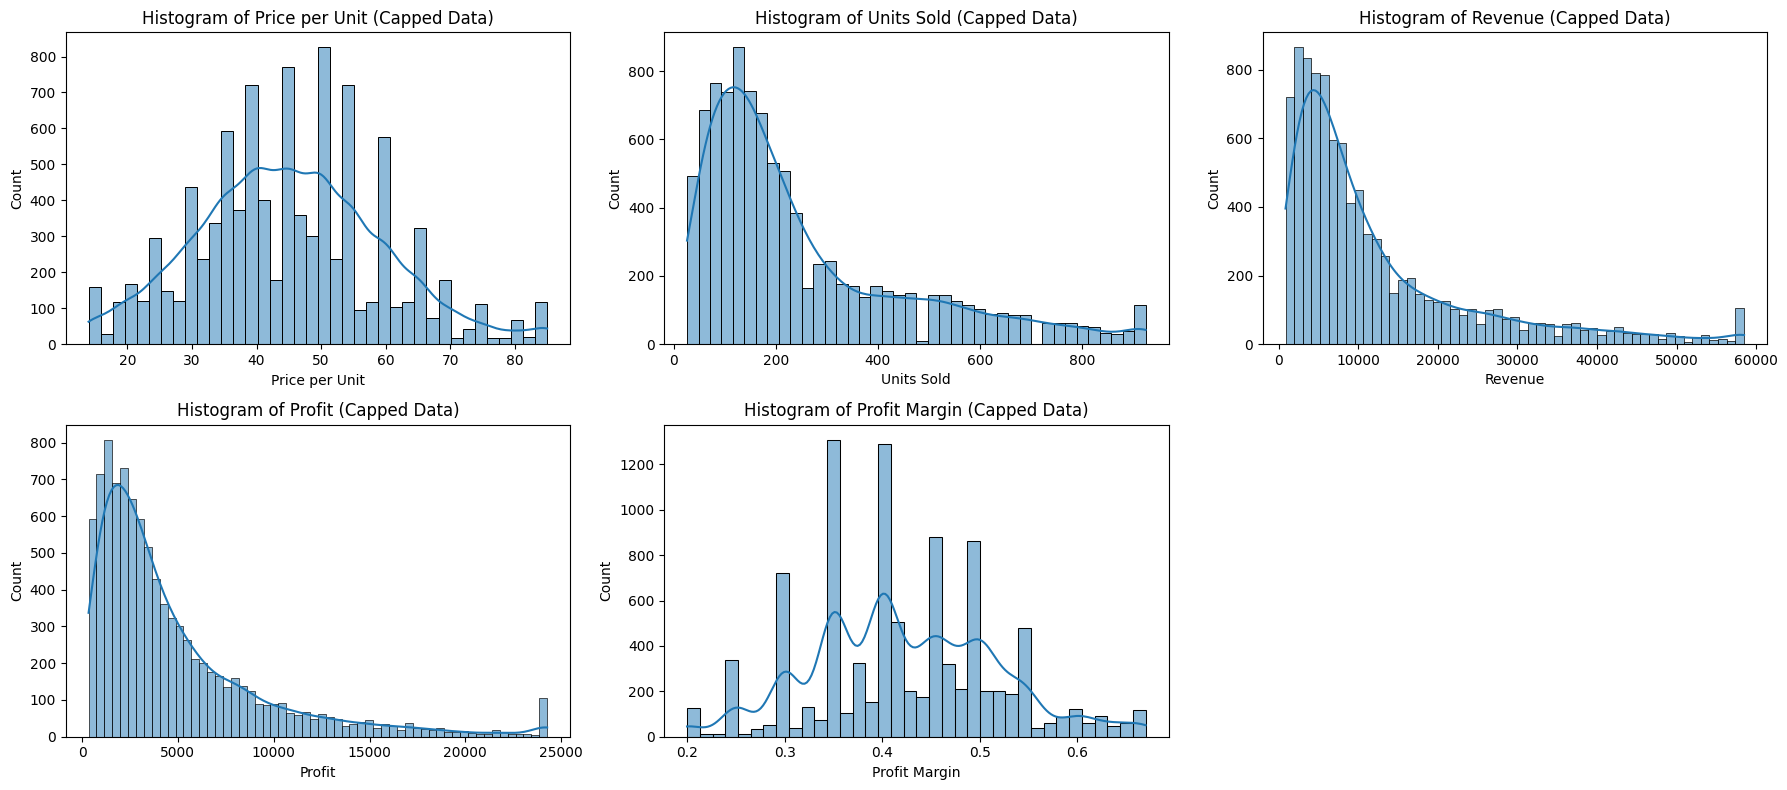

In [101]:
# Define the numerical columns for which to plot histograms (from the capped DataFrame)
numerical_cols_for_hist = ['Price per Unit', 'Units Sold', 'Revenue', 'Profit', 'Profit Margin']

plt.figure(figsize=(18, 8)) # Adjust figure size for better readability with 5 plots
for i, col in enumerate(numerical_cols_for_hist):
    plt.subplot(2, 3, i + 1)  # Create a 2 row x 3 column grid
    sns.histplot(data=df_cap, x=col, kde=True) # Use df_cap for all plots
    plt.title(f'Histogram of {col} (Capped Data)')
    plt.xlabel(col)
plt.tight_layout()
plt.show()

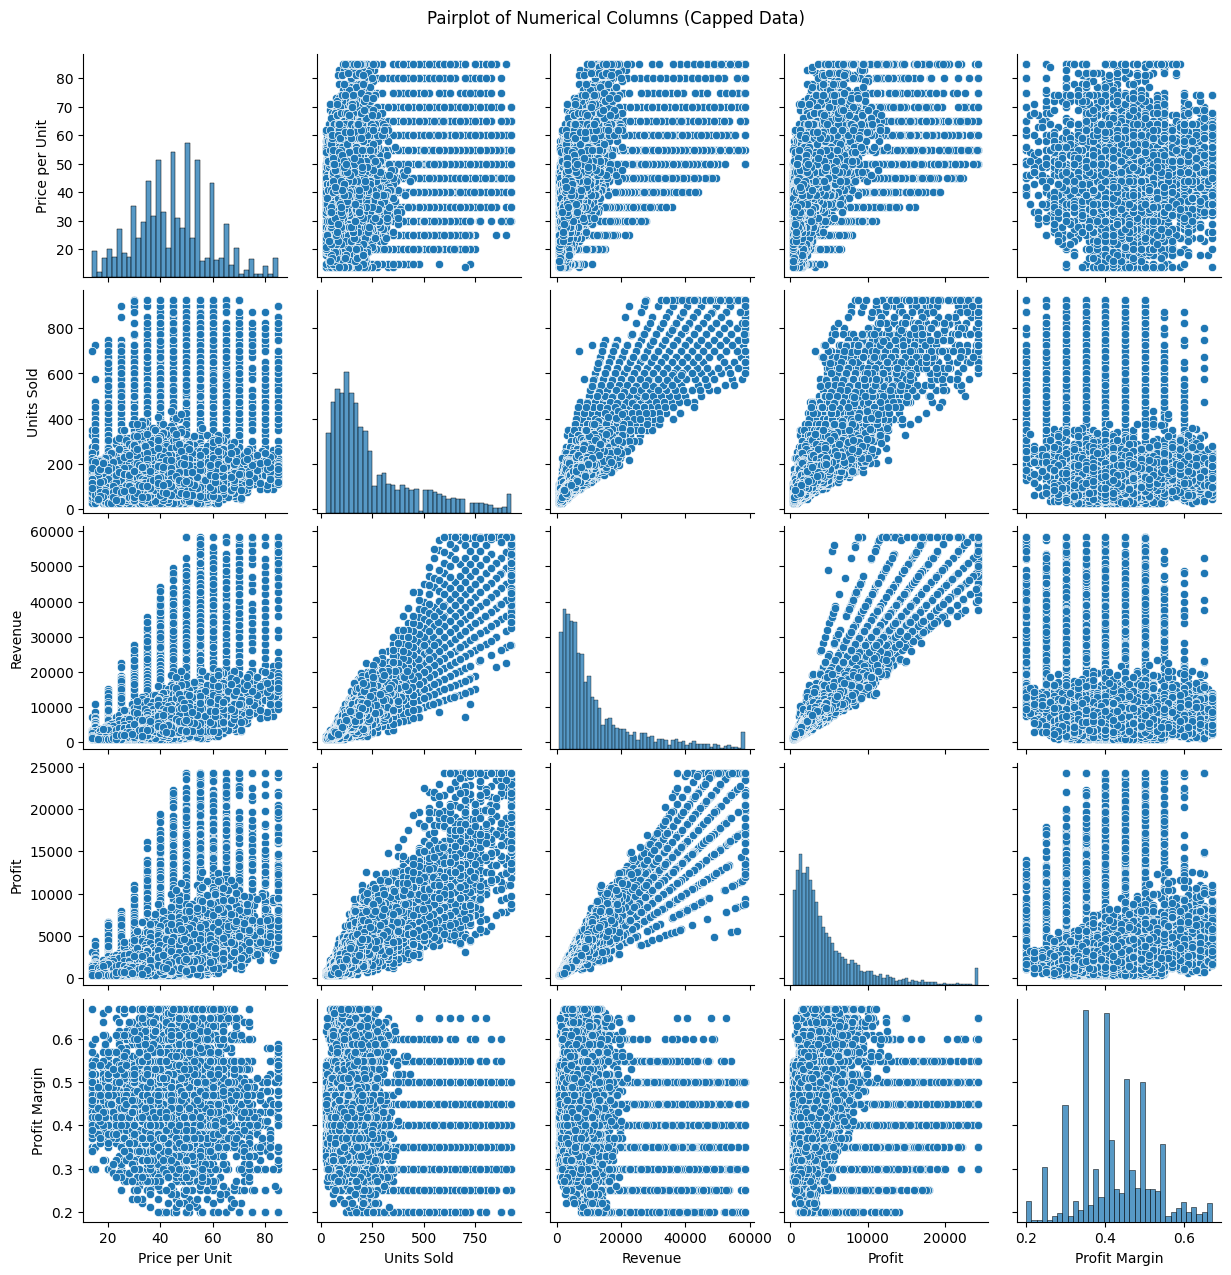

In [102]:
numerical_cols_for_pairplot = ['Price per Unit', 'Units Sold', 'Revenue', 'Profit', 'Profit Margin']
sns.pairplot(df_cap[numerical_cols_for_pairplot])
plt.suptitle('Pairplot of Numerical Columns (Capped Data)', y=1.02) # Adjust suptitle position
plt.show()

#CHƯƠNG 3: DATA VISUALIZATION

#3.1 KPI CARDS (TOTAL SALES, PROFIT, AOV)

In [103]:
import plotly.graph_objects as go

total_sales = df['Revenue'].sum()
total_profit = df['Profit'].sum()
df['AOV'] = df['Revenue'] / df['Units Sold']
avg_aov = df['AOV'].mean()

fig_kpi = go.Figure()

fig_kpi.add_trace(go.Indicator(
    mode="number",
    value=total_sales,
    title={"text": "Total Sales"},
    domain={'x': [0, 0.3], 'y': [0, 1]}
))

fig_kpi.add_trace(go.Indicator(
    mode="number",
    value=total_profit,
    title={"text": "Total Profit"},
    domain={'x': [0.35, 0.65], 'y': [0, 1]}
))

fig_kpi.add_trace(go.Indicator(
    mode="number",
    value=avg_aov,
    title={"text": "Average Order Value"},
    domain={'x': [0.7, 1], 'y': [0, 1]}
))

fig_kpi.update_layout(title="Business Overview KPI")
fig_kpi.show()

#3.1.Tổng quan hiệu quả kinh doanh

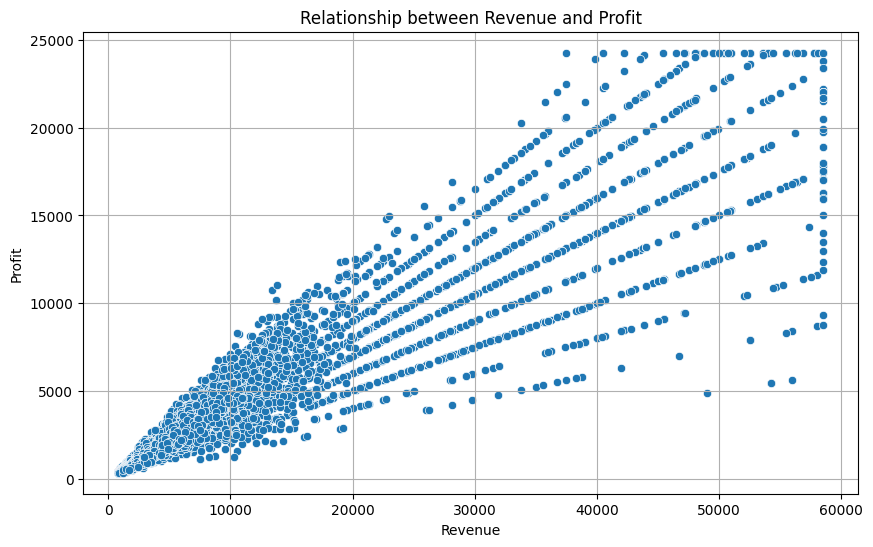

In [104]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_cap, x='Revenue', y='Profit')
plt.title('Relationship between Revenue and Profit')
plt.xlabel('Revenue')
plt.ylabel('Profit')
plt.grid(True)
plt.show()

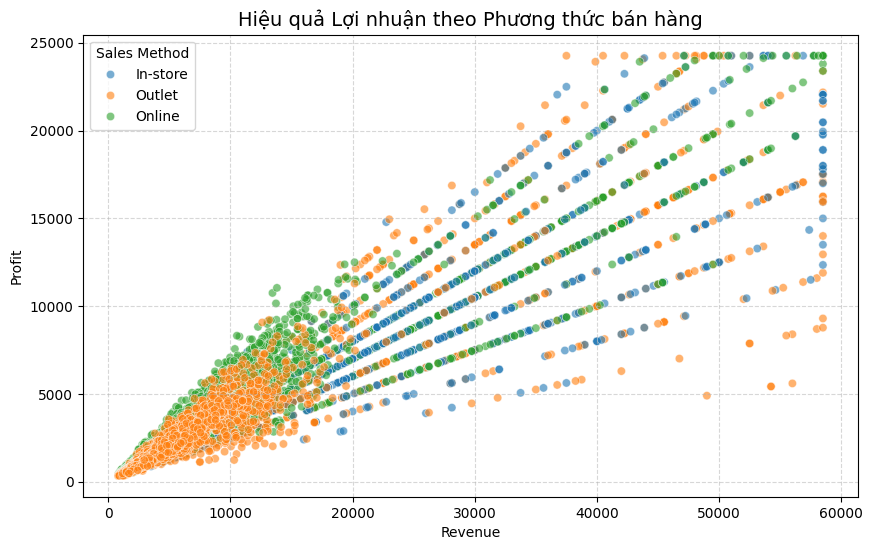

In [105]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
# Sử dụng 'hue' để phân màu theo phương thức bán hàng
sns.scatterplot(data=df_cap, x='Revenue', y='Profit', hue='Sales Method', alpha=0.6)

plt.title('Hiệu quả Lợi nhuận theo Phương thức bán hàng', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#3.2. Phân tích xu hướng doanh thu theo thời gian

/tmp/ipykernel_6479/3602731.py:8: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




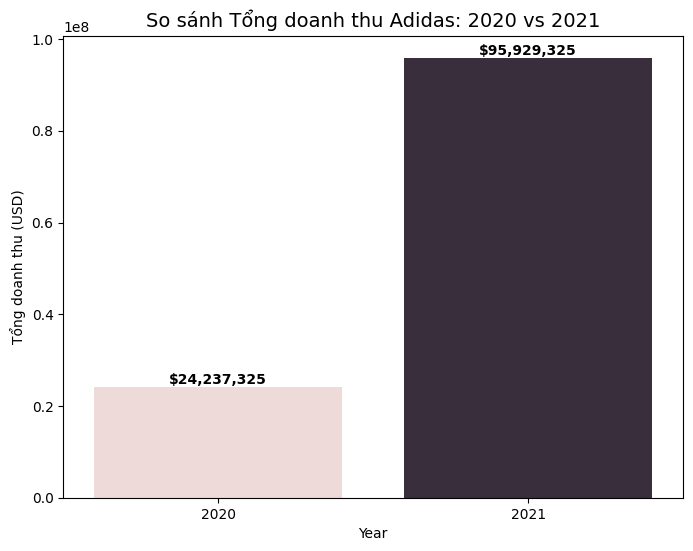

In [106]:
import matplotlib.pyplot as plt
import seaborn as sns

# Tính tổng doanh thu theo năm
yearly_revenue = df.groupby('Year')['Revenue'].sum().reset_index()

plt.figure(figsize=(8, 6))
sns.barplot(data=yearly_revenue, x='Year', y='Revenue', palette=['#f2d7d5', '#3b2c3d'])

# Thêm nhãn số liệu trên đầu cột
for i, val in enumerate(yearly_revenue['Revenue']):
    plt.text(i, val, f'${val:,.0f}', ha='center', va='bottom', fontweight='bold')

plt.title('So sánh Tổng doanh thu Adidas: 2020 vs 2021', fontsize=14)
plt.ylabel('Tổng doanh thu (USD)')
plt.show()

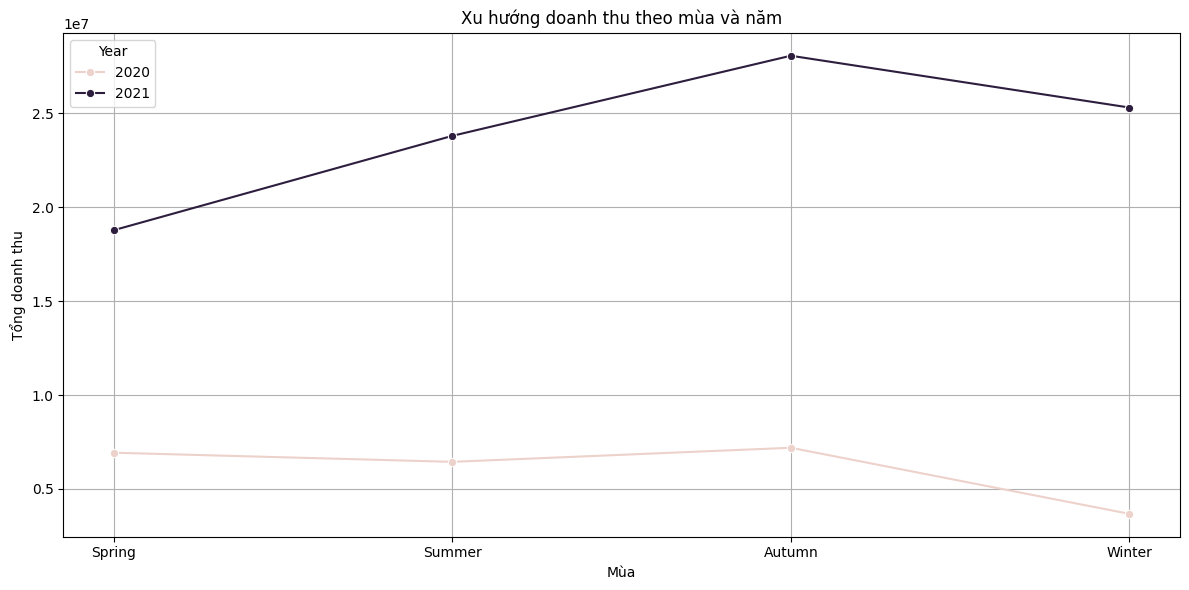

In [107]:
sales_season = df.groupby(['Year', 'Season'])['Revenue'].sum().reset_index()

# Define a custom order for seasons for proper plotting
season_order = ['Spring', 'Summer', 'Autumn', 'Winter']
sales_season['Season'] = pd.Categorical(sales_season['Season'], categories=season_order, ordered=True)

# Sort by Year and Season
sales_season = sales_season.sort_values(by=['Year', 'Season'])

plt.figure(figsize=(12, 6))
sns.lineplot(data=sales_season, x='Season', y='Revenue', hue='Year', marker='o')
plt.title('Xu hướng doanh thu theo mùa và năm')
plt.xlabel('Mùa')
plt.ylabel('Tổng doanh thu')
plt.grid(True)
plt.tight_layout()
plt.show()

/tmp/ipykernel_6479/2830380234.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



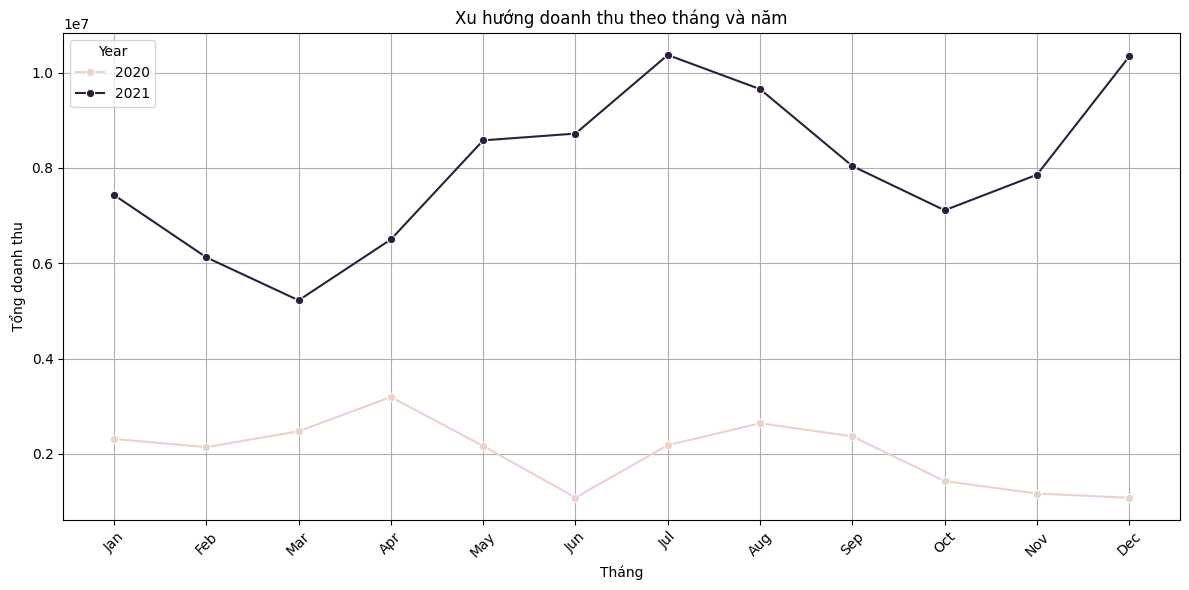

In [108]:
# Group by Year and Month_name and sum Revenue
sales_time = df.groupby(['Year', 'Month_name'])['Revenue'].sum().reset_index()

# Ensure Month_name is ordered correctly for plotting
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
sales_time['Month_name'] = pd.Categorical(sales_time['Month_name'], categories=month_order, ordered=True)

# Sort by Year and Month_name
sales_time = sales_time.sort_values(by=['Year', 'Month_name'])

plt.figure(figsize=(12, 6))
sns.lineplot(data=sales_time, x='Month_name', y='Revenue', hue='Year', marker='o')
plt.title('Xu hướng doanh thu theo tháng và năm')
plt.xlabel('Tháng')
plt.ylabel('Tổng doanh thu')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#3.3. Phân tích doanh thu theo khu vực

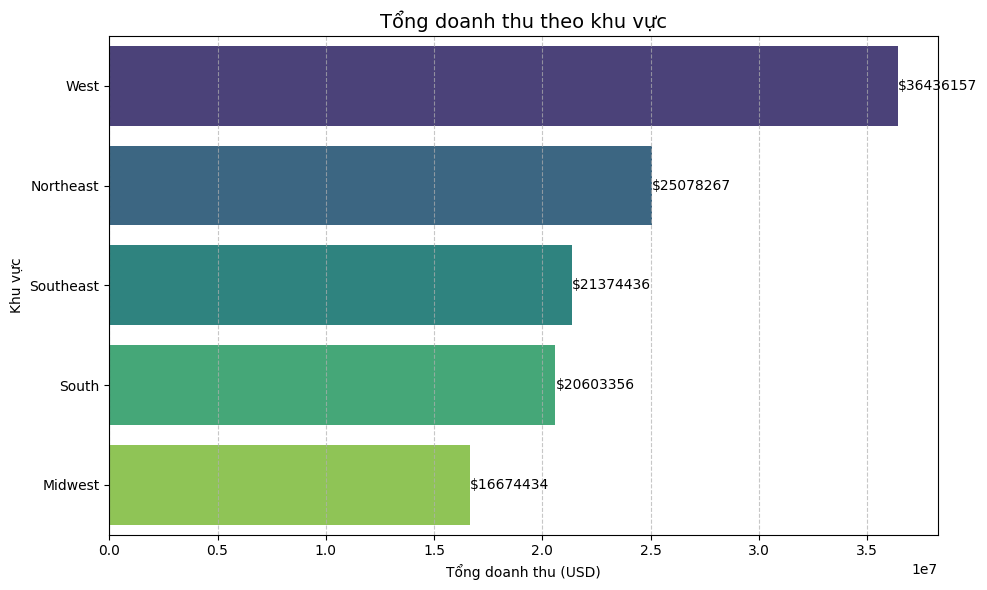

In [109]:
region_revenue = df.groupby('Region')['Revenue'].sum().reset_index()
region_revenue = region_revenue.sort_values(by='Revenue', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=region_revenue, x='Revenue', y='Region', hue='Region', palette='viridis', legend=False)

for i, (original_index, row) in enumerate(region_revenue.iterrows()):
    plt.text(row['Revenue'], i, f'${row['Revenue']:.0f}', color='black', ha="left", va='center')

plt.title('Tổng doanh thu theo khu vực', fontsize=14)
plt.xlabel('Tổng doanh thu (USD)')
plt.ylabel('Khu vực')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

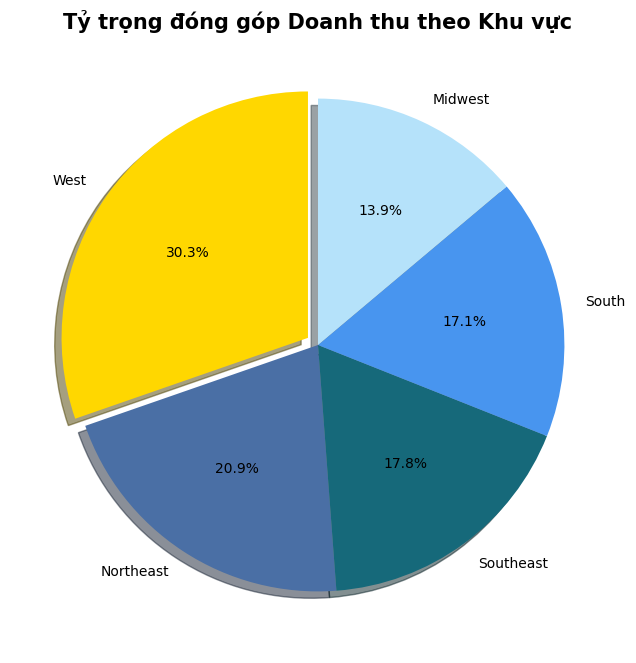

In [110]:
import matplotlib.pyplot as plt

# Dữ liệu từ biểu đồ của bạn
regions = ['West', 'Northeast', 'Southeast', 'South', 'Midwest']
revenues = [36436157, 25078267, 21374436, 20603356, 16674434]

# Màu sắc sang trọng cho báo cáo, thay đổi màu cho 'West' để dễ nhìn hơn
colors = ['#FFD700', '#4a6fa5', '#16697a', '#4895ef', '#b5e2fa'] # Đổi màu cho West thành vàng đồng

plt.figure(figsize=(10, 8))
plt.pie(revenues, labels=regions, autopct='%1.1f%%', startangle=90,
        colors=colors, explode=(0.05, 0, 0, 0, 0), shadow=True)

plt.title('Tỷ trọng đóng góp Doanh thu theo Khu vực', fontsize=15, fontweight='bold')
plt.show()

#3.4. Phân tích hiệu suất theo sản phẩm

In [111]:
import plotly.express as px

top_products = df.groupby('Product')['Revenue'].sum().reset_index()
top_products = top_products.sort_values(by='Revenue', ascending=False).head(10)

fig_product = px.bar(
    top_products,
    x='Product',
    y='Revenue',
    title='Top Products by Revenue',
    color='Revenue'
)
fig_product.show()

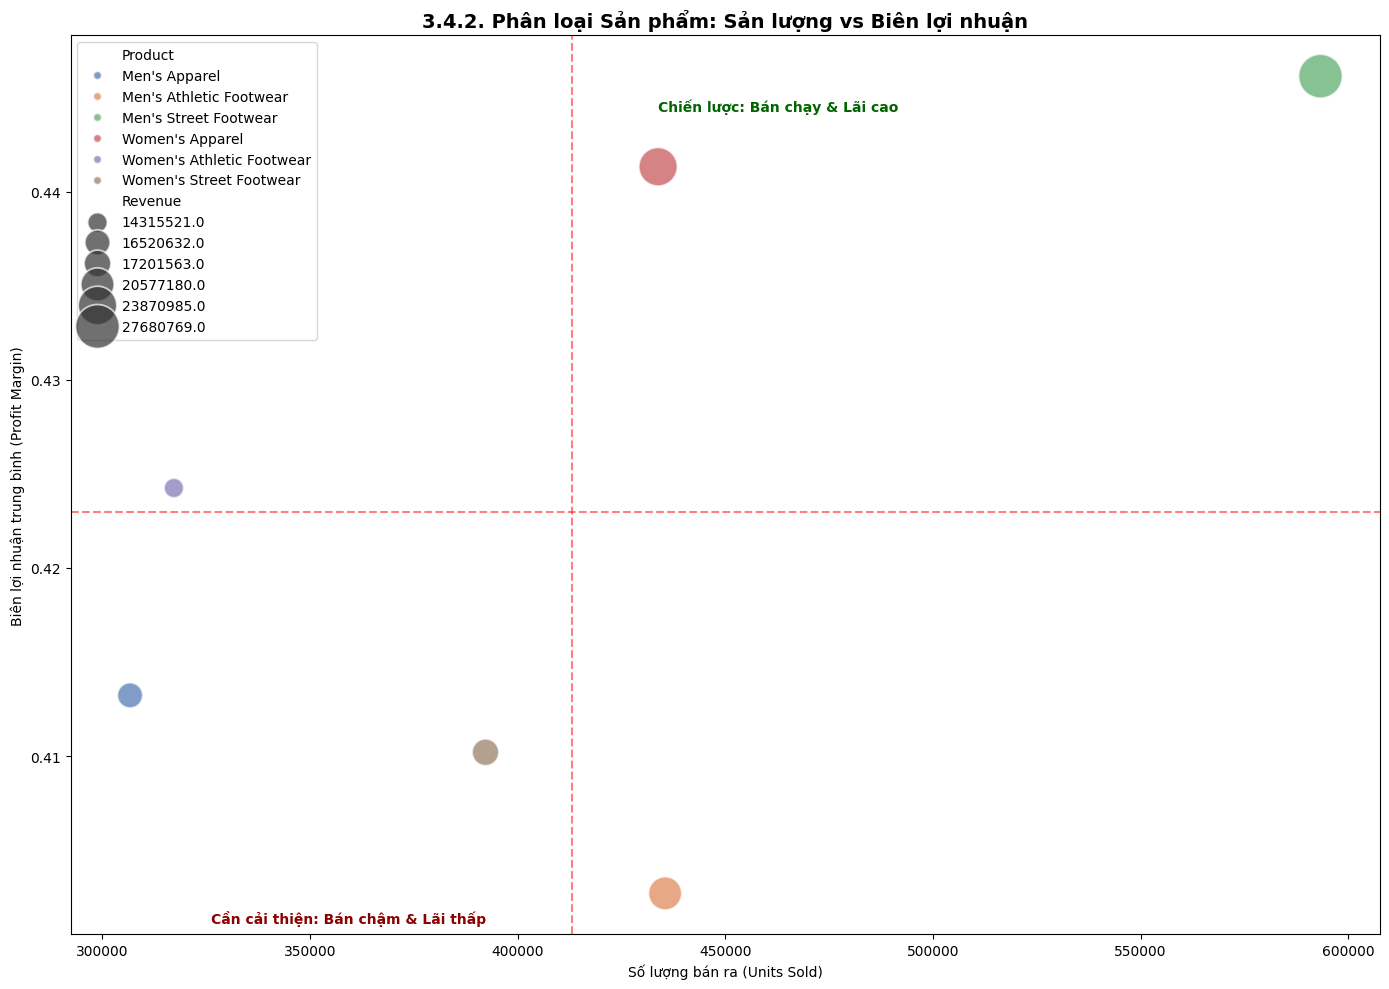

In [112]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Create product_perf DataFrame
product_perf = df.groupby('Product').agg({
    'Units Sold': 'sum',
    'Profit Margin': 'mean',
    'Revenue': 'sum'
}).reset_index()

# --- BIỂU ĐỒ 2: MA TRẬN HIỆU SUẤT (Sản lượng vs Biên lợi nhuận) ---
# Biểu đồ này giúp trả lời Insight: Bán nhiều/Lãi thấp vs Bán ít/Lãi cao
plt.figure(figsize=(14, 10)) # Tăng kích thước figure để có thêm không gian
scatter = sns.scatterplot(data=product_perf, x='Units Sold', y='Profit Margin',
                         size='Revenue', hue='Product', sizes=(200, 1000),
                         palette='deep', alpha=0.7)

# Vẽ đường trung bình để chia 4 phân hạn (Quadrants)
avg_units = product_perf['Units Sold'].mean()
avg_margin = product_perf['Profit Margin'].mean()
plt.axvline(avg_units, color='red', linestyle='--', alpha=0.5)
plt.axhline(avg_margin, color='red', linestyle='--', alpha=0.5)

plt.title('3.4.2. Phân loại Sản phẩm: Sản lượng vs Biên lợi nhuận', fontsize=14, fontweight='bold')
plt.xlabel('Số lượng bán ra (Units Sold)')
plt.ylabel('Biên lợi nhuận trung bình (Profit Margin)')

# Thêm chú thích cho các góc phần tư
# Điều chỉnh vị trí của text để tránh chồng chéo với đường trung bình nếu cần
plt.text(avg_units*1.05, avg_margin*1.05, 'Chiến lược: Bán chạy & Lãi cao', color='darkgreen', fontweight='bold', ha='left', va='bottom')
plt.text(avg_units*0.95, avg_margin*0.95, 'Cần cải thiện: Bán chậm & Lãi thấp', color='darkred', fontweight='bold', ha='right', va='top')

plt.tight_layout()
plt.show()

#3.5. Hiệu suất của nhà bán lẻ

In [113]:
retailer_sales = df.groupby('Retailer')['Revenue'].sum().reset_index()

fig_retailer = px.bar(
    retailer_sales,
    x='Retailer',
    y='Revenue',
    title='Sales by Retailer',
    color='Retailer'
)

fig_retailer.show()

In [114]:
import plotly.graph_objects as go

# Giả sử bạn đã có dataframe 'retailer_perf'

# Create retailer_perf DataFrame
retailer_perf = df.groupby('Retailer').agg({
    'Revenue': 'sum',
    'Profit Margin': 'mean'
}).reset_index()

fig = go.Figure()

# Thêm cột Doanh thu
fig.add_trace(go.Bar(x=retailer_perf['Retailer'], y=retailer_perf['Revenue'], name='Revenue'))

# Thêm đường biên lợi nhuận
fig.add_trace(go.Scatter(x=retailer_perf['Retailer'], y=retailer_perf['Profit Margin'],
                         name='Profit Margin', yaxis='y2', mode='lines+markers'))

fig.update_layout(title='Revenue vs Profit Margin by Retailer',
                  yaxis=dict(title='Revenue'),
                  yaxis2=dict(title='Profit Margin', overlaying='y', side='right'))
fig.show()

#3.6. Phân tích mối quan hệ giữa giá và doanh thu

<Figure size 1000x600 with 0 Axes>

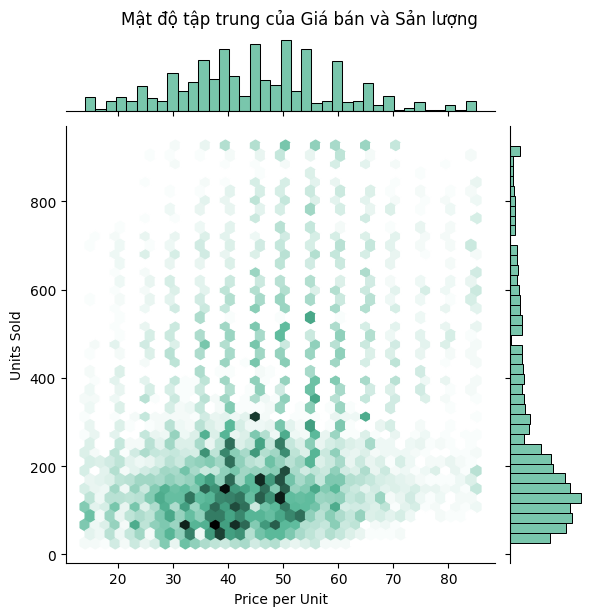

In [115]:
import seaborn as sns
import matplotlib.pyplot as plt

# Vẽ biểu đồ mật độ Hexbin để thấy vùng tập trung đơn hàng cao nhất
plt.figure(figsize=(10, 6))
sns.jointplot(data=df_cap, x='Price per Unit', y='Units Sold', kind="hex", color="#4CB391")
plt.suptitle('Mật độ tập trung của Giá bán và Sản lượng', y=1.02)
plt.show()

#3.8. Phân tích giá trị đơn hàng trung bình (AOV)

In [116]:
aov_region = df.groupby('Region')['AOV'].mean().reset_index()

fig_aov = px.bar(
    aov_region,
    x='Region',
    y='AOV',
    title='Average Order Value by Region',
    color='Region'
)

fig_aov.show()

/tmp/ipykernel_6479/668620798.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




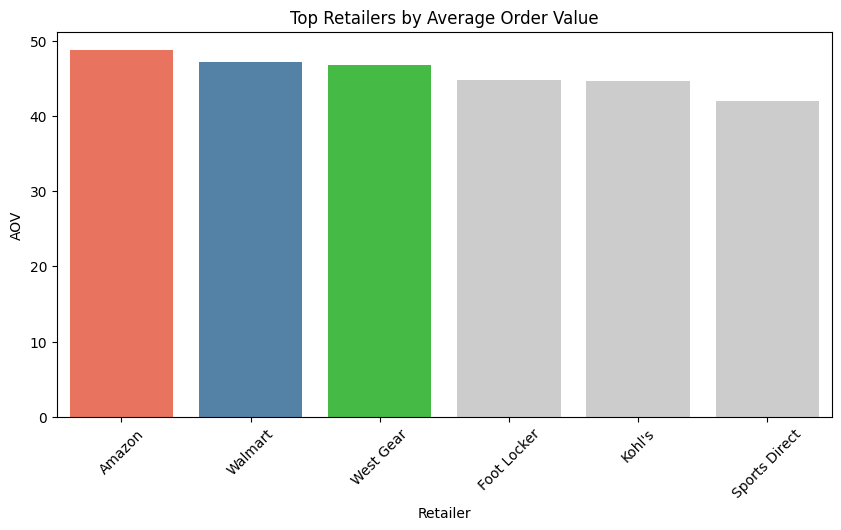

In [117]:
aov_retailer = df.groupby('Retailer')['AOV'].mean().reset_index()

# lấy top 10 cho dễ nhìn
aov_retailer = aov_retailer.sort_values(by='AOV', ascending=False).head(10)

# Tạo một bảng màu tùy chỉnh để tô màu khác cho top 3
colors = ['#FF6347', '#4682B4', '#32CD32'] # Màu cho top 3
default_color = '#CCCCCC' # Màu cho các nhà bán lẻ còn lại

# Gán màu dựa trên thứ hạng
retailer_colors = [colors[i] if i < 3 else default_color for i in range(len(aov_retailer))]

plt.figure(figsize=(10,5))
sns.barplot(data=aov_retailer, x='Retailer', y='AOV', palette=retailer_colors)

plt.title('Top Retailers by Average Order Value')
plt.xticks(rotation=45)

plt.show()

In [118]:
import plotly.graph_objects as go

# Aggregate key metrics by Retailer
retailer_metrics = df.groupby('Retailer').agg({
    'Revenue': 'mean',
    'Profit': 'mean',
    'Units Sold': 'mean',
    'Profit Margin': 'mean',
    'AOV': 'mean'
}).reset_index()

# Normalize metrics for Radar Chart (scale 0-1)
# This is important for radar charts to ensure all axes have comparable scales
metrics_to_normalize = ['Revenue', 'Profit', 'Units Sold', 'Profit Margin', 'AOV']
for col in metrics_to_normalize:
    min_val = retailer_metrics[col].min()
    max_val = retailer_metrics[col].max()
    retailer_metrics[f'{col}_normalized'] = (retailer_metrics[col] - min_val) / (max_val - min_val)

# Define the categories for the radar chart
categories = ['Revenue_normalized', 'Profit_normalized', 'Units Sold_normalized', 'Profit Margin_normalized', 'AOV_normalized']
categories_display = ['Revenue', 'Profit', 'Units Sold', 'Profit Margin', 'AOV'] # For better labels

fig_radar = go.Figure()

# Add a trace for each retailer
for index, row in retailer_metrics.iterrows():
    fig_radar.add_trace(go.Scatterpolar(
        r=[row[cat] for cat in categories],
        theta=categories_display,
        fill='toself',
        name=row['Retailer']
    ))

fig_radar.update_layout(
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[0, 1] # Normalized range
        )),
    showlegend=True,
    title='Retailer Performance Comparison (Normalized Metrics)'
)

fig_radar.show()

In [119]:
import plotly.graph_objects as go
import plotly.express as px

# Prepare data for Sankey diagram
sankey_data = df.groupby(['Region', 'Sales Method'])['Revenue'].sum().reset_index()

# Create unique lists of all sources (regions) and targets (sales methods)
sources = sankey_data['Region'].unique()
targets = sankey_data['Sales Method'].unique()

# Create mappings for nodes
node_labels = list(sources) + list(targets)
node_map = {label: i for i, label in enumerate(node_labels)}

# Generate a consistent color sequence for regions
region_colors = px.colors.qualitative.Set1[:len(sources)]
region_to_color_map = {region: color for region, color in zip(sources, region_colors)}

# Generate a consistent color sequence for sales methods (targets)
sales_method_colors = px.colors.qualitative.Plotly[len(sources):len(sources) + len(targets)]
sales_method_to_color_map = {method: color for method, color in zip(targets, sales_method_colors)}

# Build node_colors list, ensuring region nodes match their link colors
node_colors_list = []
for label in node_labels:
    if label in region_to_color_map:
        node_colors_list.append(region_to_color_map[label])
    elif label in sales_method_to_color_map:
        node_colors_list.append(sales_method_to_color_map[label])
    else:
        node_colors_list.append('#CCCCCC') # Default color for any unexpected nodes

# Create link data and assign colors based on the source region
links_source = [node_map[region] for region in sankey_data['Region']]
links_target = [node_map[method] for method in sankey_data['Sales Method']]
links_value = sankey_data['Revenue'].tolist()
links_color = [region_to_color_map[region] for region in sankey_data['Region']]

fig_sankey = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=node_labels,
        color=node_colors_list # Assign consistent colors to nodes
    ),
    link=dict(
        source=links_source,
        target=links_target,
        value=links_value,
        color=links_color # Links colors already match source regions
    )
)])

fig_sankey.update_layout(title_text="Revenue Flow from Regions to Sales Methods (with node and link colors)", font_size=10)
fig_sankey.show()